In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans  # Clase que se encarga del agrupamiento
from sklearn.preprocessing import StandardScaler  # Normalización, cambia el rango de valores de las columnas
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
caracteristicas = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
escalador = StandardScaler()
datos_escalados = escalador.fit_transform(df[caracteristicas])

# escalador = StandardScaler()   <--- Como antes se hacía
# datos_escalados = escalador.fit_transform(df)   <--- Escala todo el dataframe

In [4]:
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
etiquetas = modelo_kmeans.fit_predict(datos_escalados)
df['Cluster'] = etiquetas
df

C:\Users\CC6\anaconda3\envs\prueba9d\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,2
146,147,6.3,2.5,5.0,1.9,Iris-virginica,0
147,148,6.5,3.0,5.2,2.0,Iris-virginica,2
148,149,6.2,3.4,5.4,2.3,Iris-virginica,2


C:\Users\CC6\AppData\Local\Temp\ipykernel_2796\1826441970.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


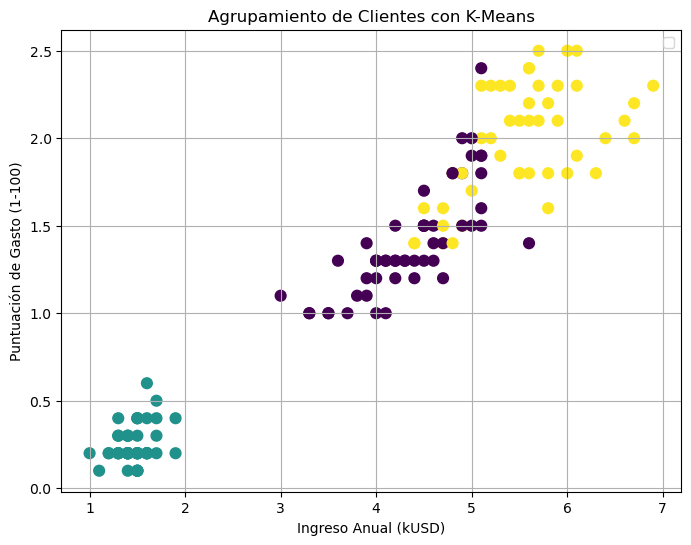

In [5]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=df['Cluster'], cmap='viridis', s=60)
centroides_originales = escalador.inverse_transform(modelo_kmeans.cluster_centers_)
# plt.scatter(centroides_originales[:, 0], centroides_originales[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Agrupamiento de Clientes con K-Means')
plt.xlabel('Ingreso Anual (kUSD)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

In [7]:
inercias = []
puntajes_silueta = []
rango_k = range(2, 9)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(datos_escalados)
    
    inercias.append(kmeans.inertia_)
    
    score = silhouette_score(datos_escalados, etiquetas)
    puntajes_silueta.append(score)

C:\Users\CC6\anaconda3\envs\prueba9d\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\CC6\anaconda3\envs\prueba9d\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\CC6\anaconda3\envs\prueba9d\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\CC6\anaconda3\envs\prueba9d\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

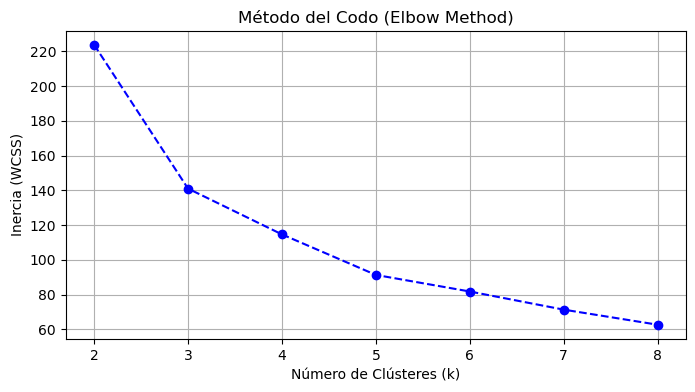

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (WCSS)')
plt.grid(True)
plt.show()

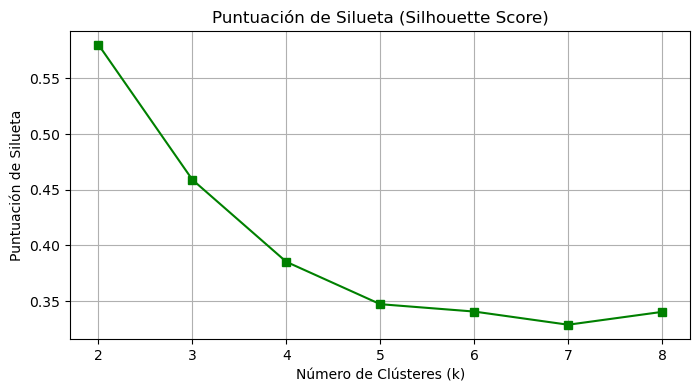

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(rango_k, puntajes_silueta, marker='s', linestyle='-', color='g')
plt.title('Puntuación de Silueta (Silhouette Score)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Puntuación de Silueta')
plt.grid(True)
plt.show()